# P9.2 Determine numerically (looking for the eigenvector) values of ergodic density for the random walk on selected network. [1P]


Node   | Numerical  | Analytical | Difference
----------------------------------------------
0      | 0.090909   | 0.090909   | 0.000000
1      | 0.062771   | 0.062771   | 0.000000
2      | 0.071429   | 0.071429   | 0.000000
3      | 0.038961   | 0.038961   | 0.000000
4      | 0.017316   | 0.017316   | 0.000000
5      | 0.030303   | 0.030303   | 0.000000
6      | 0.028139   | 0.028139   | 0.000000
7      | 0.028139   | 0.028139   | 0.000000
8      | 0.036797   | 0.036797   | 0.000000
9      | 0.006494   | 0.006494   | 0.000000
10     | 0.017316   | 0.017316   | 0.000000
11     | 0.006494   | 0.006494   | 0.000000
12     | 0.008658   | 0.008658   | 0.000000
13     | 0.036797   | 0.036797   | 0.000000
14     | 0.010823   | 0.010823   | 0.000000
15     | 0.015152   | 0.015152   | 0.000000
16     | 0.012987   | 0.012987   | 0.000000
17     | 0.006494   | 0.006494   | 0.000000
18     | 0.006494   | 0.006494   | 0.000000
19     | 0.010823   | 0.010823   | 0.000000
20     | 0.008658   | 0.008

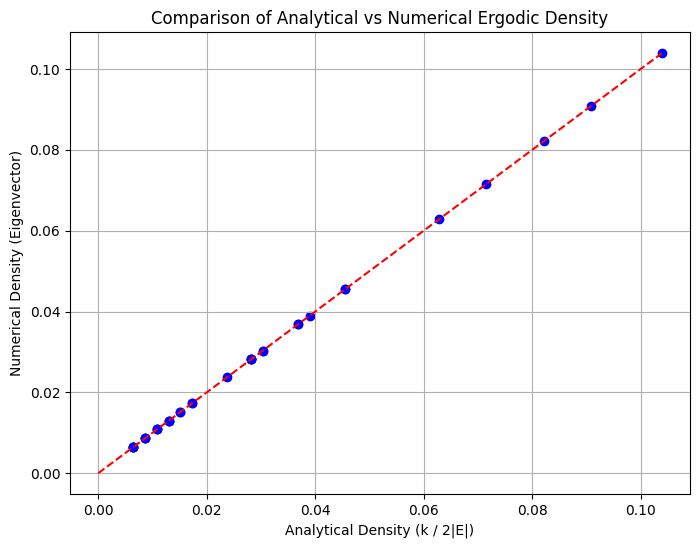

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
num_nodes = len(G.nodes)
num_edges = len(G.edges)

degrees = np.sum(A, axis=0)
P = np.zeros((num_nodes, num_nodes))

for i in range(num_nodes):
    for j in range(num_nodes):
        if degrees[i] > 0:
            P[j, i] = A[i, j] / degrees[i]


eigenvalues, eigenvectors = np.linalg.eig(P)

index_ev1 = np.argmin(np.abs(eigenvalues - 1))
stationary_vector = eigenvectors[:, index_ev1].real


ergodic_density_numerical = stationary_vector / np.sum(stationary_vector)
ergodic_density_analytical = degrees / np.sum(degrees)

print(f"{'Node':<6} | {'Numerical':<10} | {'Analytical':<10} | {'Difference':<10}")
print("-" * 46)
for i in range(num_nodes):
    diff = abs(ergodic_density_numerical[i] - ergodic_density_analytical[i])
    print(f"{i:<6} | {ergodic_density_numerical[i]:.6f}   | {ergodic_density_analytical[i]:.6f}   | {diff:.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(ergodic_density_analytical, ergodic_density_numerical, color='blue')
plt.plot([0, max(ergodic_density_analytical)], [0, max(ergodic_density_analytical)], 'r--')
plt.xlabel('Analytical Density (k / 2|E|)')
plt.ylabel('Numerical Density (Eigenvector)')
plt.title('Comparison of Analytical vs Numerical Ergodic Density')
plt.grid(True)
plt.show()

# P9.3 Determine dynamically (by iterating the Markov operator) ergodic density for the random walk on selected network. [1P]

Converged in 146 iterations.
Node   | Dynamic    | Eigenvector | Diff      
----------------------------------------------
0      | 0.090909   | 0.090909   | 0.000000
1      | 0.062771   | 0.062771   | 0.000000
2      | 0.071429   | 0.071429   | 0.000000
3      | 0.038961   | 0.038961   | 0.000000
4      | 0.017316   | 0.017316   | 0.000000
5      | 0.030303   | 0.030303   | 0.000000
6      | 0.028139   | 0.028139   | 0.000000
7      | 0.028139   | 0.028139   | 0.000000
8      | 0.036797   | 0.036797   | 0.000000
9      | 0.006494   | 0.006494   | 0.000000


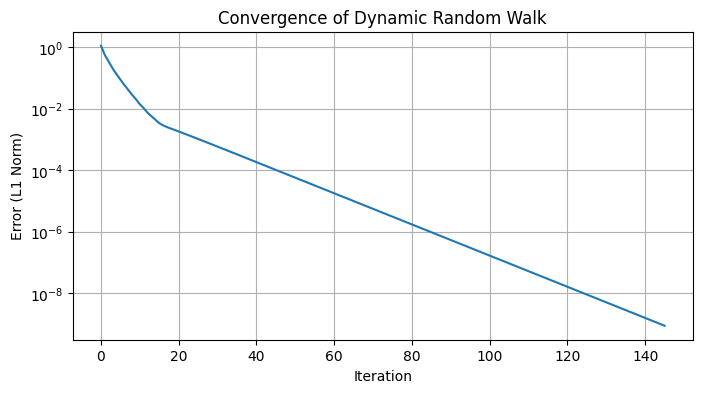

In [7]:
import numpy as np
import matplotlib.pyplot as plt

pi_dynamic = np.random.rand(num_nodes)
pi_dynamic = pi_dynamic / np.sum(pi_dynamic)


tolerance = 1e-9
max_iter = 1000
diff = 1.0
iterations = 0

history = []

while diff > tolerance and iterations < max_iter:
    pi_next = P.dot(pi_dynamic)
    
    diff = np.linalg.norm(pi_next - pi_dynamic, ord=1)
    pi_next = pi_next / pi_next.sum()
    pi_dynamic = pi_next
    history.append(diff)
    iterations += 1

print(f"Converged in {iterations} iterations.")

print(f"{'Node':<6} | {'Dynamic':<10} | {'Eigenvector':<10} | {'Diff':<10}")
print("-" * 46)
for i in range(min(10, num_nodes)):
    d_dyn = pi_dynamic[i]
    d_eig = ergodic_density_numerical[i]
    print(f"{i:<6} | {d_dyn:.6f}   | {d_eig:.6f}   | {abs(d_dyn - d_eig):.6f}")

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (L1 Norm)')
plt.title('Convergence of Dynamic Random Walk')
plt.grid(True)
plt.show()

# P9.5 Determine the value of classic or modified pagerank for the selected network. [1.5P]

In [12]:
import networkx as nx
import numpy as np

G = nx.karate_club_graph()
N = len(G)

d = 0.85
pr_nx = nx.pagerank(G, alpha=d)

A = nx.to_numpy_array(G)

degrees = np.sum(A, axis=1)

P = np.zeros((N, N))
for i in range(N):
    if degrees[i] == 0:
        P[:, i] = 1.0 / N
    else:
        P[:, i] = A[i, :] / degrees[i]

J = np.ones((N, N)) / N
G_matrix = d * P + (1 - d) * J

pi = np.ones(N) / N

tolerance = 1e-12
max_iter = 10000

for _ in range(max_iter):
    pi_next = G_matrix.dot(pi)
    pi_next = pi_next / pi_next.sum()

    if np.linalg.norm(pi_next - pi, 1) < tolerance:
        pi = pi_next
        break

    pi = pi_next

print(f"{'Node':<6} | {'NetworkX':<10} | {'Manual':<10} | {'Diff':<10}")
print("-" * 46)
for i in range(10):
    val_nx = pr_nx[i]
    val_man = pi[i]
    print(f"{i:<6} | {val_nx:.6f}   | {val_man:.6f}   | {abs(val_nx - val_man):.6f}")


Node   | NetworkX   | Manual     | Diff      
----------------------------------------------
0      | 0.088508   | 0.088500   | 0.000008
1      | 0.057415   | 0.057412   | 0.000003
2      | 0.062767   | 0.062766   | 0.000001
3      | 0.037212   | 0.037210   | 0.000002
4      | 0.020504   | 0.020501   | 0.000003
5      | 0.033810   | 0.033804   | 0.000007
6      | 0.031529   | 0.031523   | 0.000006
7      | 0.026465   | 0.026463   | 0.000001
8      | 0.033382   | 0.033382   | 0.000001
9      | 0.009463   | 0.009463   | 0.000000


# P9.6 Find a graph with a fixed number of edges and vertices where diffusion occurs fastest (hint: value a second eigenvalue can help). [3.5P]


Processing Scenario 1: Small Ring (N=20)
  -> Started: 1.0000
  -> Finished: 1.0000

Processing Scenario 2: Medium Scale-Free (N=50)
  -> Started: 0.7978
  -> Finished: 0.7266

Processing Scenario 3: Large Random (N=100)
  -> Started: 0.6432
  -> Finished: 0.5773


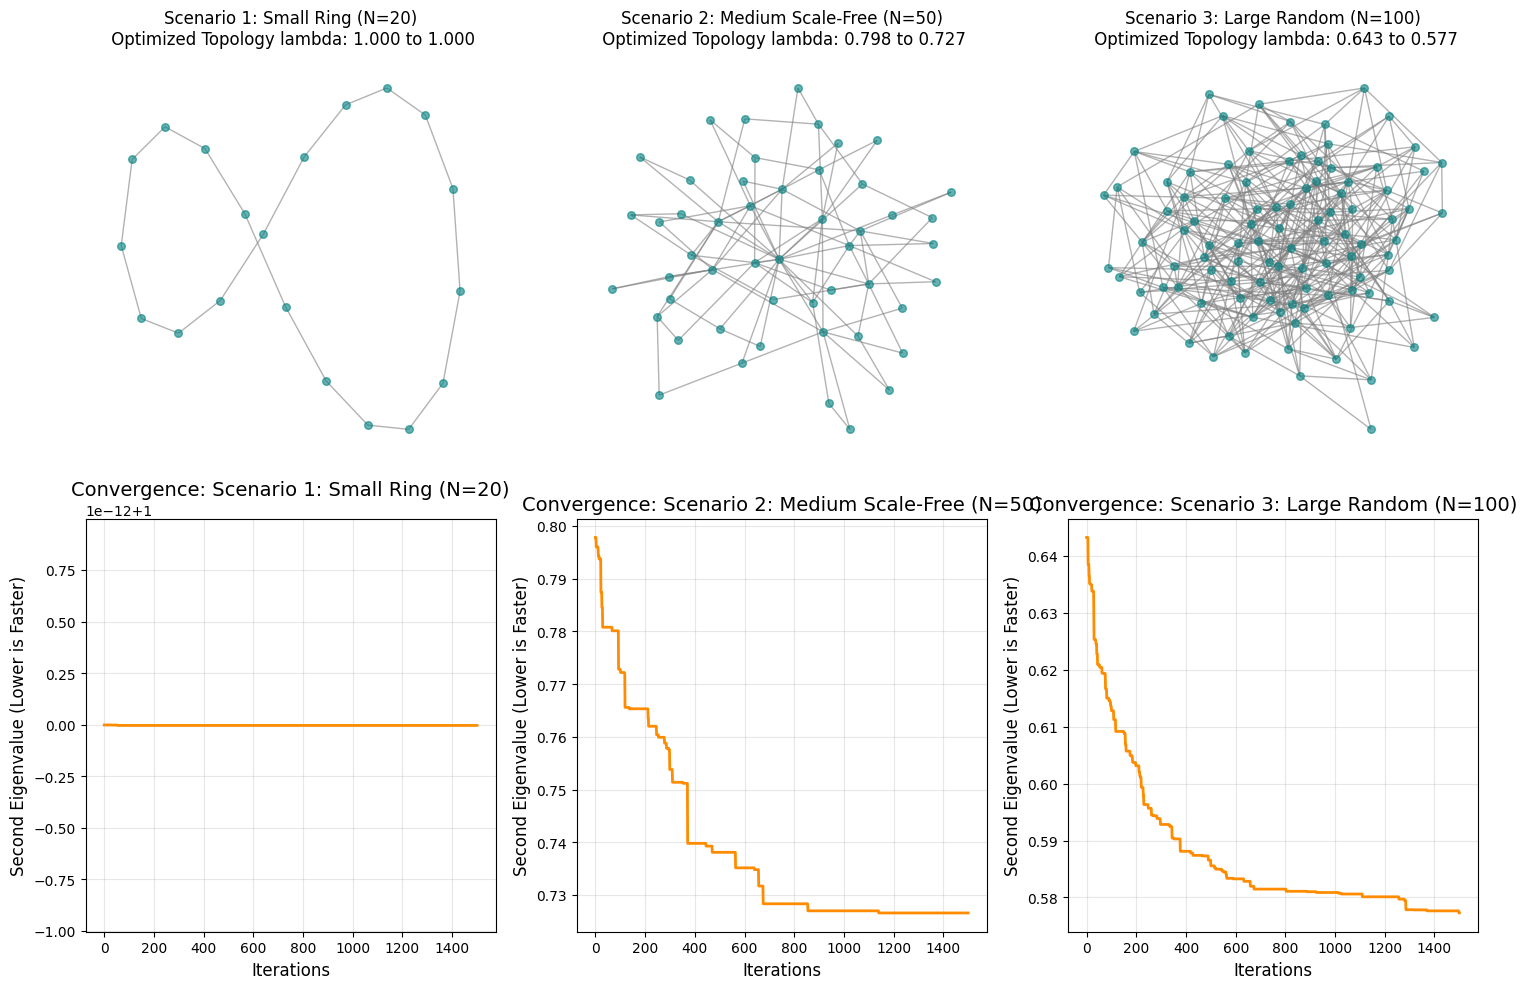

In [15]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

def get_second_eigenvalue(G):
    """Calculates the second largest eigenvalue modulus (SLEM)."""
    if not nx.is_connected(G):
        return 1.0 
    
    A = nx.to_numpy_array(G)
    degrees = np.sum(A, axis=0)
    
    degrees[degrees == 0] = 1 
    
    P = np.zeros_like(A)
    for i in range(len(G)):
        if np.sum(A[:, i]) > 0:
            P[:, i] = A[:, i] / degrees[i]
            
    evals = np.linalg.eigvals(P)
    evals_sorted = np.sort(np.abs(evals))[::-1]
    
    return evals_sorted[1] if len(evals_sorted) > 1 else 0.0

def optimize_graph(G_start, iterations=1000):
    """Hill-climbing optimization to minimize lambda_2."""
    G_curr = G_start.copy()
    current_lambda = get_second_eigenvalue(G_curr)
    history = [current_lambda]
    
    for _ in range(iterations):
        edges = list(G_curr.edges())
        if len(edges) < 2: break
        
        e1, e2 = random.sample(edges, 2)
        u, v = e1
        x, y = e2
        
        if len({u, v, x, y}) == 4 and not G_curr.has_edge(u, x) and not G_curr.has_edge(v, y):
            
            G_curr.remove_edge(u, v)
            G_curr.remove_edge(x, y)
            G_curr.add_edge(u, x)
            G_curr.add_edge(v, y)
            
            if nx.is_connected(G_curr):
                new_lambda = get_second_eigenvalue(G_curr)
                if new_lambda < current_lambda:
                    current_lambda = new_lambda
                else:
                    G_curr.remove_edge(u, x)
                    G_curr.remove_edge(v, y)
                    G_curr.add_edge(u, v)
                    G_curr.add_edge(x, y)
            else:
                G_curr.remove_edge(u, x)
                G_curr.remove_edge(v, y)
                G_curr.add_edge(u, v)
                G_curr.add_edge(x, y)
                
        history.append(current_lambda)
        
    return G_curr, history

scenarios = [
    {
        "name": "Scenario 1: Small Ring (N=20)",
        "N": 20,
        "type": "ring",
        "k": 2
    },
    {
        "name": "Scenario 2: Medium Scale-Free (N=50)",
        "N": 50,
        "type": "barabasi",
        "m": 2
    },
    {
        "name": "Scenario 3: Large Random (N=100)",
        "N": 100,
        "type": "random",
        "p": 0.08
    }
]

results = []

plt.figure(figsize=(15, 10))

for idx, sc in enumerate(scenarios):
    N = sc["N"]
    print(f"\nProcessing {sc['name']}")
    
    if sc["type"] == "ring":
        G_initial = nx.watts_strogatz_graph(N, k=sc["k"], p=0.0)
    elif sc["type"] == "barabasi":
        G_initial = nx.barabasi_albert_graph(N, m=sc["m"])
    elif sc["type"] == "random":
        G_initial = nx.erdos_renyi_graph(N, p=sc["p"])
        while not nx.is_connected(G_initial):
            G_initial = nx.erdos_renyi_graph(N, p=sc["p"])
            
    lambda_start = get_second_eigenvalue(G_initial)
    
    G_opt, history = optimize_graph(G_initial, iterations=1500)
    lambda_end = history[-1]
    
    print(f"  -> Started: {lambda_start:.4f}")
    print(f"  -> Finished: {lambda_end:.4f}")
    

    plt.subplot(2, 3, idx + 1)
    pos = nx.spring_layout(G_opt, seed=42)
    nx.draw(G_opt, pos, node_size=30, node_color='teal', edge_color='gray', alpha=0.6)
    plt.title(f"{sc['name']}\n Optimized Topology lambda: {lambda_start:.3f} to {lambda_end:.3f}")
    plt.axis('off')

    plt.subplot(2, 3, idx + 4)
    plt.plot(history, color='darkorange', linewidth=2)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Second Eigenvalue (Lower is Faster)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.title(f"Convergence: {sc['name']}", fontsize=14)

plt.tight_layout()
plt.show()
